<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/examples/BE3Dv6-SingleScreen-Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
- This is an example for DNMT3A which is based on a CBE screen

# Setup

In [1]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,678 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,040 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70

In [2]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-ybakt8ie
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-ybakt8ie
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit 04b7b4c73ece592074433b52765f509ad44c3bc2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.4 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=762995 sha256=a4fcfcfd9610bfc36368168035d8c1ea7712d60fac2987734dfc42a6d5b6c7f0
  Stored in directory: /tmp/pip-ephem-wheel-cache-tk44pvis/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filename=

In [4]:
# @title Download relevant files

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/dnmt3a.pdb -O dnmt3a.pdb
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol.tsv -O NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol.tsv
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/dnmt3a.yaml -O dnmt3a.yaml


--2026-02-12 18:37:24--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/dnmt3a.pdb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 588545 (575K) [text/plain]
Saving to: ‘dnmt3a.pdb’

dnmt3a.pdb          100%[===================>] 574.75K  --.-KB/s    in 0.06s   

2026-02-12 18:37:24 (9.25 MB/s) - ‘dnmt3a.pdb’ saved [588545/588545]

--2026-02-12 18:37:24--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, await

In [5]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


# Input
Run one of the code blocks in this section, but not both

In [6]:
# @title Required (filled with default values for DNMT3A)

beclust3d_path = '../' # @param {type:"string"}

# @markdown Input Gene and UniprotID (for AF2 structure)
input_gene = 'DNMT3A' # @param {type:"string"}
input_uniprot = 'Q9Y6K1' # @param {type:"string"}
structureid = f"AF-{input_uniprot}-F1-model_v4"

# @markdown Screen File (TSV)
screen_dir = '' # @param {type:"string"}
screens = 'NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol.tsv' # @param {type:"string"}

mut_list_col = ""
mut_col = "Mut_type" # @param {type:"string"}
val_col = "sgRNA_score" # @param {type:"string"}
gene_col = "Gene" # @param {type:"string"}
edits_col = "Mutation_list" # @param {type:"string"}
gRNA_col = "" # @param {type:"string"}

# @markdown ---

# @markdown # Optional
qa_passed_only = False # @param {type:"boolean"}
function_for_lfc = 'max' #@param {type:"string"}
function_for_lfc3d = 'mean' #@param {type:"string"}
# function_for_meta = 'SUM' #@param {type:"string"}

nRandom = 500 #@param
single_pthr = 0.05 #@param
single_pthr_str = str(single_pthr).split('.')[1]
# multi_pthr = 0.001 #@param
# multi_pthr_str = str(multi_pthr).split('.')[1]

# @markdown Where files and plots are stored:
workdir = '' # @param {type:"string"}
job_id = '' # @param {type:"string"}
# @markdown Radius to calculate LFC3D over:
structure_radius = 6.0 # @param {type:"number"}
# @markdown Radius to cluster over:
clustering_radius = 6.0 # @param {type:"number"}

# @markdown Optional user-provided filepaths
user_fasta = '' # @param {type:"string"}
if len(user_fasta) == 0: user_fasta = None
user_pdb = 'dnmt3a.pdb' # @param {type:"string"}
if len(user_pdb) == 0: user_pdb = None
user_dssp = '' # @param {type:"string"}
if len(user_dssp) == 0: user_dssp = None
input_chain = 'A' # @param {type:"string"}

# Load screen names and dataframes
if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(',')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

# Parameters for conservation and cross chain
conservation_run = False
v_score_threshold = 3
alt_gene_name = None # @param {type:"string"}
alt_uniprot_id = None # @param {type:"string"}
alt_screen_start = None
priority_on_alternative = False
ppi_chain_gene_dict = None
ppi_gene_edits_dict = None
atom_level_naa = False

# @markdown Mutation parameters
qa_only = False # @param {type:"boolean"}
mut_categories = ["Nonsense", "Splice", "Missense", "No Mutation", "Silent"] # @param {type:"raw"}
mut_delimiter = ',' # @param {type:"string"}
prioritize_by_sequence_mutations = ['Missense', 'Silent', 'Nonsense']
qa_cases = ['Nonsense', 'Splice']
qa_controls = ['No Mutation']

# @markdown Conservation parameters
target_res_pos = None # @param {type:"string"}
target_res = None # @param {type:"string"}
alternate_res_pos = None # @param {type:"string"}
alternate_res = None # @param {type:"string"}

# Assign job ID and create an output directory
if len(job_id) == 0:
    job_id = str(uuid.uuid4())
    print(f"Job ID: {job_id}")

output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 863c67db-3e96-4b7f-bc5c-101b8829b727
All results will be saved in the following directory:
DNMT3A-Job-863c67db-3e96-4b7f-bc5c-101b8829b727


In [6]:
# @title Required (yml file input)

def load_config(config_yaml):
    with open(config_yaml, "r") as file:
        config = yaml.safe_load(file)
    return config

config_yaml = 'dnmt3a.yaml' #@param {type:"string"}
config = load_config(config_yaml)

# Parameters

beclust3d_path = config['beclust3d_path']
if beclust3d_path is None: beclust3d_path = ""

input_gene = config['input_gene']
input_uniprot = config['input_uniprot']
structureid = f"AF-{input_uniprot}-F1-model_v4"

screen_dir = config['screen_dir']
if screen_dir is None: screen_dir = ""
screens = config['screens']

mut_list_col = config['database']['mut_list_col']
mut_col = config['database']['mut_col']
val_col = config['database']['val_col']
gene_col = config['database']['gene_col']
edits_col = config['database']['edits_col']
gRNA_col = config['database']['gRNA_col']

qa_passed_only = config['qa']['qa_passed_only']
function_for_lfc = config['function_for_lfc']
function_for_lfc3d = config['function_for_lfc3d']
function_for_meta = config['function_for_meta']

nRandom = config['nRandom']
single_pthr = config['pthr']['single_screen']
single_pthr_str = str(single_pthr).split('.')[1]
multi_pthr = config['pthr']['multi_screen']
multi_pthr_str = str(multi_pthr).split('.')[1]

workdir = config['output_dir']
if workdir is None: workdir = ""
structure_radius = config['structure_radius']
clustering_radius = config['clustering_radius']

user_fasta = config['user_fasta']
user_pdb = config['user_pdb']
user_dssp = config['user_dssp']
input_chain = config['input_chain']

if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(', ')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

mutation_category = config['mutation_category']
mut_categories = list()
mut_categories.extend(config['mutation_category']['nonsense'])
mut_categories.extend(config['mutation_category']['splice'])
mut_categories.extend(config['mutation_category']['missense'])
mut_categories.extend(config['mutation_category']['silent'])
mut_categories.extend(config['mutation_category']['no_mutation'])
mut_categories.extend(config['mutation_category']['intron'])
mut_delimiter = config['database']['mut_delimiter']

# Parameters for cross chain
conservation_run=config['conservation']['run']
v_score_threshold = config['conservation']['v_score_threshold']
alt_gene_name=config['conservation']['alt_gene_name']
alt_uniprot_id=config['conservation']['alt_uniprot_id']
alt_screen_start = config['conservation']['alt_screen_start']
priority_on_alternative = config['priority_on_alternative'],
ppi_chain_gene_dict = config['ppi_chain_gene_dict']
ppi_gene_edits_dict = config['ppi_gene_edits_dict']
atom_level_naa = config['atom_level_naa']

qa_only = config['qa']['qa_only']
qa_controls = config['qa']['controls']
qa_cases = config['qa']['cases']

prioritize_by_sequence_mutations = list()
prioritize_by_sequence_mutations.extend(config['mutation_category']['missense'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['silent'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['nonsense'])
if not qa_cases:
    qa_cases = list()
    qa_cases.extend(config['mutation_category']['nonsense'])
    qa_cases.extend(config['mutation_category']['splice'])
if not qa_controls:
    qa_controls = list()
    qa_controls.extend(config['mutation_category']['no_mutation'])
    qa_controls.extend(config['mutation_category']['silent'])

# @markdown Conservation parameters
target_res_pos = None
target_res = None
alternate_res_pos = None
alternate_res = None

job_id = str(uuid.uuid4())
print(f"Job ID: {job_id}")
workdir = config['output_dir']
output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 526fa003-feac-4024-af2b-fc3f534b4b9b
All results will be saved in the following directory:
/content/DNMT3A-Job-526fa003-feac-4024-af2b-fc3f534b4b9b


# Running BE3D

In [7]:
# @title Parse structure

# Parse structure
struc_df = sequence_structural_features(
    output_dir,
    input_gene, input_uniprot, structureid,
    user_fasta=user_fasta, user_pdb=user_pdb, user_dssp=user_dssp,
    target_chainid=input_chain,
    radius=structure_radius,
    atom_level_naa=atom_level_naa,
    )

df_residuemap = pd.DataFrame()
pdb_file = os.path.join(output_dir, "sequence_structure", f"{structureid}_processed.pdb")
atom_level = pdb_file if atom_level_naa == True else False

# Compile list of genes and conservation
conserv_dfs = list()
gene_list = list()
for screen_name in screen_names:
    if alt_screen_start and screen_name.startswith(alt_screen_start):
        conserv_dfs.append(df_residuemap)
        gene_list.append(alt_gene_name)
    else:
        conserv_dfs.append(None)
        gene_list.append(input_gene)


In [8]:
# @title Preprocessing input

comparison_name = 'NonsenseSplice_vs_SilentNoMut'
# For all screens
hypothesis_test(
    output_dir,
    input_dfs, screen_names,
    cases=qa_cases, controls=qa_controls,
    comp_name=comparison_name,
    mut_col=mut_col, val_col=val_col, gene_col=gene_col,
    save_type='svg',
    )

# @markdown Optional parameters for filtering to only QA passed screens
stat_test_option = 'KolmogorovSmirnov' # @param ["KolmogorovSmirnov", "MannWhitney"]
hyp_option = 'hypothesis2' # @param ["hypothesis1", "hypothesis2"]
stat_test_pval = 0.05 # @param {type:"number"}

# If we only want to run the pipeline on screens passing QC
if qa_passed_only:

    # Load statistical test and identify screens which pass the cutoff
    h2_ks_test_pd = pd.read_csv(f'{output_dir}/hypothesis_qc/{stat_test_option}_{hyp_option}.tsv', sep='\t')
    h2_ks_test_pd = h2_ks_test_pd.replace(-999, None)
    white_screen_list = h2_ks_test_pd[
        (h2_ks_test_pd[f'p_{comparison_name}'] < stat_test_pval) & (h2_ks_test_pd['gene_name'].isin(gene_list))]['screenid'].to_list()
    print(f'Original screen size: {len(screen_names)}')
    print(f'Screen white list size: {len(white_screen_list)}')
    print(f'QA-passed screen size: {len(list(set(screen_names).intersection(white_screen_list)))}')
    screen_names = list(set(screen_names).intersection(white_screen_list))
    assert len(screen_names) > 0, 'No QA-passed screens found'

    # Overwrite the previous lists if we want to only focus on QA passed screens
    # Compile list of genes and conservation
    input_dfs = [pd.read_csv(f'{screen_dir}{s}.tsv', sep='\t') for s in screen_names]
    conserv_dfs = list()
    gene_list = list()
    for screen_name in screen_names:
        if alt_screen_start and screen_name.startswith(alt_screen_start):
            conserv_dfs.append(df_residuemap)
            gene_list.append(alt_gene_name)
        else:
            conserv_dfs.append(None)
            gene_list.append(input_gene)

# For all screens, parse the data and separate by gene and mutation type
parse_be_data(
    output_dir,
    input_dfs, input_gene, screen_names,
    mut_col=mut_col, val_col=val_col, gene_col=gene_col, edits_col=edits_col,
    mut_categories=mut_categories, mut_delimiter=mut_delimiter,
    conserv_dfs = conserv_dfs, conserv_col=alternate_res_pos,
    gene_list=gene_list,
    v_score_threshold=v_score_threshold,
    )
plot_rawdata(
    output_dir,
    input_dfs, screen_names,
    mut_col=mut_col, val_col=val_col, gene_col=gene_col,
    mut_categories=mut_categories,
    )


Processing NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol
{'Nonsense': 18, 'Splice': 12, 'Missense': 204, 'Silent': 88, 'No Mutation': 60, 'Intron': 163}


In [9]:
# @title Preprocessing input

# For all screens
df_missense_list = [
    pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_Missense.tsv',
                sep='\t') for gene, screen_name in zip(gene_list, screen_names)
]

# For all screens
for df_missense, screen_name, gene in zip(df_missense_list, screen_names, gene_list):
    randomize_data(
        df_missense,
        output_dir, gene,
        screen_name,
        nRandom=nRandom,
        seed=True,
        )

df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')

# For all screens (human and non-human mixed)
for gene, screen_name, df_consrv in zip(gene_list, screen_names, conserv_dfs):
    df_control = pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_No_Mutation.tsv', sep='\t', index_col=0)
    df_dict = {}

    for mut in prioritize_by_sequence_mutations:
        filepath = f'{output_dir}/screendata/{gene}_{screen_name}_{mut}.tsv'
        if os.path.exists(filepath):
            df_dict[mut] = pd.read_csv(filepath, sep='\t', index_col=0)

    if df_consrv is not None:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name,
            target_res_pos=target_res_pos,
            alt_res_pos=alternate_res_pos,
            alt_res=alternate_res
        )
    else:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name
        )

    df_rand = pd.read_csv(f'{output_dir}/screendata_rand/{gene}_{screen_name}_Missense_rand.tsv.gz', sep='\t')

    # For all screens
    randomize_sequence(
        df_missense, df_rand,
        output_dir,
        gene, screen_name,
        nRandom=nRandom, conservation=False,
        muttype='Missense',
        function_name=function_for_lfc,
        target_pos='unipos', target_res=None,
        )

    plot_screendata_sequence(
        df_missense,
        output_dir,
        gene, screen_name, function_name=function_for_lfc, muttype='Missense',
    )


In [10]:
# @title BE Clust3D: Calculating LFC3D score per residue and clustering without aggregation

def find_union(input, pthr_str):
    if input[0] == f'p<{pthr_str}' or input[1] == f'p<{pthr_str}':
        return f'p<{pthr_str}'
    else:
        return f'p>={pthr_str}'

def run_Clust3D_per_species(
    gene, screen_names, gene_type,
    output_dir, structureid, pdb_file, input_chain,
    function_for_lfc, function_for_lfc3d,
    single_pthr, single_pthr_str, atom_level,
    clustering_max_distance=25, conserved_only=False, pthrs=[0.05, 0.01, 0.001],
    ):

    # CLUSTERING ON INDIVIDUAL SCREENS
    df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')
    df_edits_list = []
    df_rand_list = []

    for screen_name in screen_names:
        df_missense = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        temp_plab_label, temp_p_label = f'{function_for_lfc}_Missense_LFC_plab_input', f'{function_for_lfc}_Missense_LFC_p'
        df_missense[temp_plab_label] = df_missense[temp_p_label].apply(lambda x: f'p<{single_pthr_str}' if x < single_pthr else f'p>={single_pthr_str}')

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_missense,
            output_dir, gene,
            psig_columns=[temp_plab_label],
            pthr_cutoffs=[f'p<{single_pthr_str}'],
            screen_name=screen_name, score_type='lfc',
            max_distances=clustering_max_distance, merge_cols=['unipos', 'chain'],
            atom_level=atom_level,
        )

        df_protein_edits = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        df_edits_list.append(df_protein_edits)
        df_protein_edits_rand = pd.read_csv(f'{output_dir}/screendata_sequence_rand/{gene}_{screen_name}_Missense_protein_edits_rand.tsv.gz', sep='\t')
        df_rand_list.append(df_protein_edits_rand)

    df_LFC_LFC3D = calculate_lfc3d(
        df_struc, df_edits_list, df_rand_list,
        output_dir, gene, screen_names,
        nRandom=nRandom,  muttype='Missense',
        function_type_lfc=function_for_lfc, function_type_lfc3d=function_for_lfc3d,
        conserved_only=conserved_only,
        gene_type=gene_type, target_gene_chain=input_chain,
        ppi_chain_gene_dict=ppi_chain_gene_dict, ppi_gene_edits_dict=ppi_gene_edits_dict
    )

    # SPLIT, BIN, PLOT, CLUSTERING ON LFC AND LFC3D #
    # NO AGGREGATION #
    for score_type in ['LFC', 'LFC3D']:
        # SPLIT, BIN, PLOT #
        df_bidir = average_split_score(
            df_LFC_LFC3D,
            output_dir, gene, screen_names,
            score_type=score_type, gene_type=gene_type,
        )
        df_dis, _, _ = bin_score(
            df_bidir,
            output_dir, gene, screen_names,
            score_type=score_type, gene_type=gene_type,
        )
        znorm_score(
            df_bidir, output_dir, gene, screen_names,
            pthrs=pthrs, score_type=score_type, gene_type=gene_type,
        )
        df_score_type = pd.read_csv(f'{output_dir}/{score_type}/{gene_type}_{gene}_NonAggr_{score_type}.tsv', sep='\t')

        for screen_name in screen_names:
            average_split_bin_plots(
                df_score_type,
                workdir = output_dir, input_gene = gene,
                screen_name=screen_name, # BLANK FOR META #
                func='', # BLANK FOR NON AGGR #
                pthr=single_pthr, score_type=score_type,
                aggregate_dir=score_type, save_type='svg'
                )

        df_pvals = pd.read_csv(f'{output_dir}/{score_type}/{gene_type}_{gene}_NonAggr_{score_type}.tsv', sep='\t')

        for screen_name in screen_names:
            # CLUSTERING #
            df_hits_clust, distances, yvalues = clustering(
                df_struc, df_pvals,
                output_dir, gene,
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig', f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig', f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig', f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                max_distances=20, merge_cols=['unipos', 'chain'],
                atom_level=atom_level,
            )

            # PLOTTING CLUSTERING #
            plot_clustering(
                df_struc, df_pvals,
                df_hits_clust, clustering_radius,
                output_dir, gene,
                distances, yvalues,
                names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig', f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig', f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig',f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                merge_col=['unipos', 'chain'],
                save_type='svg',
                dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
            )

    for screen_name in screen_names:
        # LFC vs LFC3D SCATTERPLOT #
        df_lfc = pd.read_csv(f"{output_dir}/LFC/{gene_type}_{gene}_NonAggr_LFC.tsv", sep='\t')
        df_lfc_dis = pd.read_csv(f"{output_dir}/LFC/{gene_type}_{gene}_LFC_dis_wght.tsv", sep='\t')
        df_lfc3d = pd.read_csv(f"{output_dir}/LFC3D/{gene_type}_{gene}_NonAggr_LFC3D.tsv", sep='\t')
        df_lfc3d_dis = pd.read_csv(f"{output_dir}/LFC3D/{gene_type}_{gene}_LFC3D_dis_wght.tsv", sep='\t')

        df_dis_input = pd.DataFrame()
        df_dis_input['unipos'] = df_lfc_dis['unipos']

        df_dis_input = pd.concat([df_dis_input,
                                  df_lfc_dis.filter(regex=r'LFC$'),
                                  df_lfc3d_dis.filter(regex=r'LFC3D$'),
                                  df_lfc3d.filter(regex=fr'LFC3D_dis$|{single_pthr_str}_psig$')
                                  ])
        df_dis_input = df_dis_input.rename({f'{screen_name}_LFC3D_neg_{single_pthr_str}_psig': f'{screen_name}_LFC3D_neg_psig',
                                            f'{screen_name}_LFC3D_pos_{single_pthr_str}_psig': f'{screen_name}_LFC3D_pos_psig', }, axis=1)
        lfc_lfc3d_scatter(
            df_input=df_dis_input,
            workdir=output_dir,
            input_gene=gene, screen_name=screen_name,
            pthr=single_pthr,
        )
        os.rename(f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter.png',
                  f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter_{single_pthr_str}_{screen_name}.png')

    # Load both LFC and LFC3D dataframes
    df_pvals_LFC3D = pd.read_csv(f'{output_dir}/LFC3D/{gene_type}_{gene}_NonAggr_LFC3D.tsv', sep='\t')
    df_pvals_LFC = pd.read_csv(f'{output_dir}/LFC/{gene_type}_{gene}_NonAggr_LFC.tsv', sep='\t')
    df_pvals = pd.concat([df_pvals_LFC3D, df_pvals_LFC.drop(columns=['unipos', 'unires', 'chain'])], axis=1)

    # Find union of LFC and LFC3D and perform clustering
    for screen_name in screen_names:
        for each_pthr in ['05', '01', '001']:
            # Find negative union
            temp_union_label = f'{screen_name}_union_neg_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_neg_{each_pthr}_psig', f'{screen_name}_LFC3D_neg_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)
            # Find positive union
            temp_union_label = f'{screen_name}_union_pos_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_pos_{each_pthr}_psig', f'{screen_name}_LFC3D_pos_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)

        # CLUSTERING #
        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_pvals,
            output_dir, gene,
            psig_columns=[
                f'{screen_name}_union_neg_05_psig', f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig', f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig', f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name=screen_name, score_type='union',
            max_distances=20, merge_cols=['unipos', 'chain'],
            atom_level = pdb_file if atom_level_naa == True else False,
        )

        # PLOTTING CLUSTERING #
        plot_clustering(
            df_struc, df_pvals,
            df_hits_clust, clustering_radius,
            output_dir, gene,
            distances, yvalues,
            names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
            psig_columns=[
                f'{screen_name}_union_neg_05_psig', f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig', f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig', f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name = screen_name, score_type='union',
            merge_col=['unipos', 'chain'],
            save_type='svg',
            dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
        )

    return df_LFC_LFC3D

screen_names_temp = [x[1] for x in zip(conserv_dfs, screen_names) if x[0] is None]
merged_df_LFC_LFC3D = run_Clust3D_per_species(
    input_gene, screen_names_temp, gene_type='Original',
    output_dir=output_dir, structureid=structureid, pdb_file=pdb_file, input_chain=input_chain,
    function_for_lfc=function_for_lfc, function_for_lfc3d=function_for_lfc3d,
    single_pthr=single_pthr, single_pthr_str=single_pthr_str, atom_level=atom_level,
    )


Calculated LFC3D for NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol


In [11]:
# @markdown G2P Formatting

gene_list = [input_gene] * len(screen_names)
input_gene_g2p = f'Original_{input_gene}'

g2p_formatted_hit_cluster(
    output_dir, gene_list, screen_names,
    lfc_pthr=single_pthr_str, lfc3d_pthr=single_pthr_str,
    meta_pthr='001', conservation=conservation_run,
    input_gene=input_gene_g2p,
    )

DNMT3A NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol


In [12]:
# @title Download output directory
download_directory = False #@param {type:"boolean"}
if download_directory:
    shutil.make_archive(output_dir, 'zip', output_dir)
    files.download(f"{output_dir}.zip")


# Analysis

In [13]:
# @title LFC, LFC3D Residue-dot Plot

screen_name = screen_names[0]

# Load LFC data
lfc_pd = pd.read_csv(f'{output_dir}/LFC/Original_DNMT3A_NonAggr_LFC.tsv', sep='\t')
lfc_pd = lfc_pd.replace('-', None)
lfc_pd[f'{screen_name}_LFC_pos'] = pd.to_numeric(lfc_pd[f'{screen_name}_LFC_pos'], errors='coerce')

# Load LFC3D data
lfc3d_pd = pd.read_csv(f'{output_dir}/LFC3D/Original_DNMT3A_NonAggr_LFC3D.tsv', sep='\t')
lfc3d_pd = lfc3d_pd.replace('-', None)
lfc3d_pd[f'{screen_name}_LFC3D_pos'] = pd.to_numeric(lfc3d_pd[f'{screen_name}_LFC3D_pos'], errors='coerce')

# Map significance to color arrays
lfc_colors = lfc_pd[f'{screen_name}_LFC_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc3d_colors = lfc3d_pd[f'{screen_name}_LFC3D_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')

# Shared axis ranges
x_min = min(lfc_pd['unipos'].min(), lfc3d_pd['unipos'].min())
x_max = max(lfc_pd['unipos'].max(), lfc3d_pd['unipos'].max())
y_min = min(lfc_pd[f'{screen_name}_LFC_pos'].min(), lfc3d_pd[f'{screen_name}_LFC3D_pos'].min())
y_max = max(lfc_pd[f'{screen_name}_LFC_pos'].max(), lfc3d_pd[f'{screen_name}_LFC3D_pos'].max())

# Create subplots
fig = make_subplots(
    rows=1, cols=2, subplot_titles=('LFC', 'LFC3D'),
    shared_xaxes=True, shared_yaxes=True)

# Plot LFC
fig.add_trace(go.Scatter(
    x=lfc_pd['unipos'],
    y=lfc_pd[f'{screen_name}_LFC_pos'],
    mode='markers',
    marker=dict(color=lfc_colors, size=10),
    showlegend=False
), row=1, col=1)

# Plot LFC3D
fig.add_trace(go.Scatter(
    x=lfc3d_pd['unipos'],
    y=lfc3d_pd[f'{screen_name}_LFC3D_pos'],
    mode='markers',
    marker=dict(color=lfc3d_colors, size=10),
    showlegend=False
), row=1, col=2)

# # Add horizontal reference lines at y=0
# for col in [1, 2]:
#     fig.add_shape(type='line',
#                   x0=x_min, x1=x_max,
#                   y0=0, y1=0,
#                   line=dict(color='black', width=1, dash='dot'),
#                   row=1, col=col)

# Add manual legend (dummy invisible points with legend)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='blue'),
    name='p < 0.05'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='gray'),
    name='p > 0.05'
), row=1, col=1)

# Layout and axes

fig.update_layout(
    height=600,
    width=1400,
    title_text="DNMT3A Residue-level LFC and LFC3D Plot",
    legend=dict(x=1.05, y=1, traceorder="normal"),
)

fig.update_xaxes(title_text="Residue Position", range=[x_min, x_max])
fig.update_yaxes(title_text="Signal", range=[y_min, y_max+0.3])

fig.show()

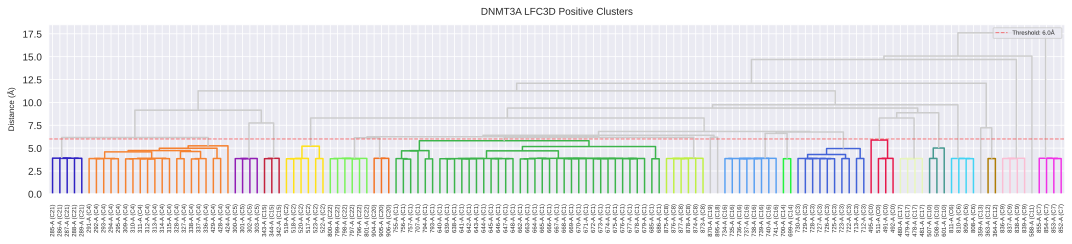

In [14]:
# @title LFC3D Hit Clusters (Dendrogram)
display(SVG(filename=f'{output_dir}/cluster_LFC3D/plots/DNMT3A_NZL-DNMT3A-CBE-LueNatChemBiol2022_negcontrol_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))